In [11]:
import sys
import os
sys.path.append(os.path.abspath(".."))


In [12]:
import networkx as nx
from disparity_filter import DisparityFilter
from noise_corrected import NoiseCorrectedFilter
from shared import generate_graph_from_adjmx_nx, show_graph, describe_network, save_filtered_graph, dataset_backbone_combinations
import numpy as np
from config import PERCENTILE, MIN_DEGREE, ALPHA, DATASET_LIST

In [13]:
def updateHT(originalH5, state_of_nodes, name):
    new_size = len(list(filter(lambda x : x, state_of_nodes)))
    newH5 = np.zeros((originalH5.shape[0], new_size))
    
    i = 0
    for (index, node_state) in enumerate(state_of_nodes):
        if node_state:
            newH5[:, i] = originalH5[:, index]
            i+=1
    
    np.save(f"../dataset/npy/{name}.npy", newH5)
    
    return newH5

In [14]:
# methods = ["disp_fil", "nois_corr"]
# datasets = ["metr-la", "pems-bay"]
# data_types = ["metr-la", "pems-bay"]
# # alphas = [0.01, 0.05]
# cuts = [f"alpah_filter{str(ALPHA).replace('.', '_')}", f"percen_filter{str(PERCENTILE).replace('.', '_')}"]

# combinations = list(itertools.product( methods, cuts))
combinations = dataset_backbone_combinations()
combinations

[('disp_fil', 'alpah_filter0_1'),
 ('disp_fil', 'percen_filter0_3'),
 ('nois_corr', 'alpah_filter0_1'),
 ('nois_corr', 'percen_filter0_3')]

Rede Original - METR-LA:
  Nós: 207
  Arestas: 1520
  Redução de arestas: 0.0%
O grafo é Direcionado: False


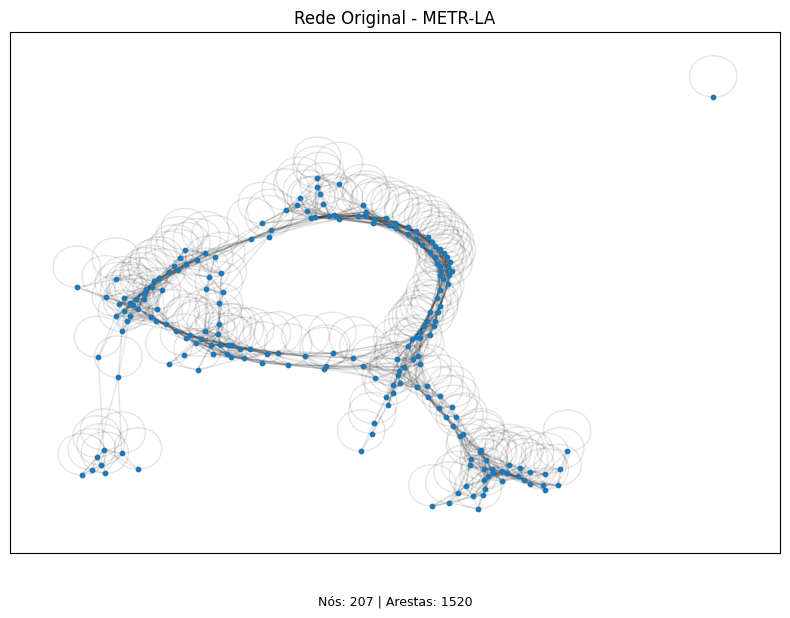

  Nós originais: 207
  Arestas originais: 1520
  Nós filtrados: 138
  Arestas filtradas: 155
  Redução: 89.8%
Disparity Filter - alpah_filter0_1 - metr-la:
  Nós: 138
  Arestas: 155
  Redução de arestas: 0.0%
O grafo é Direcionado: False


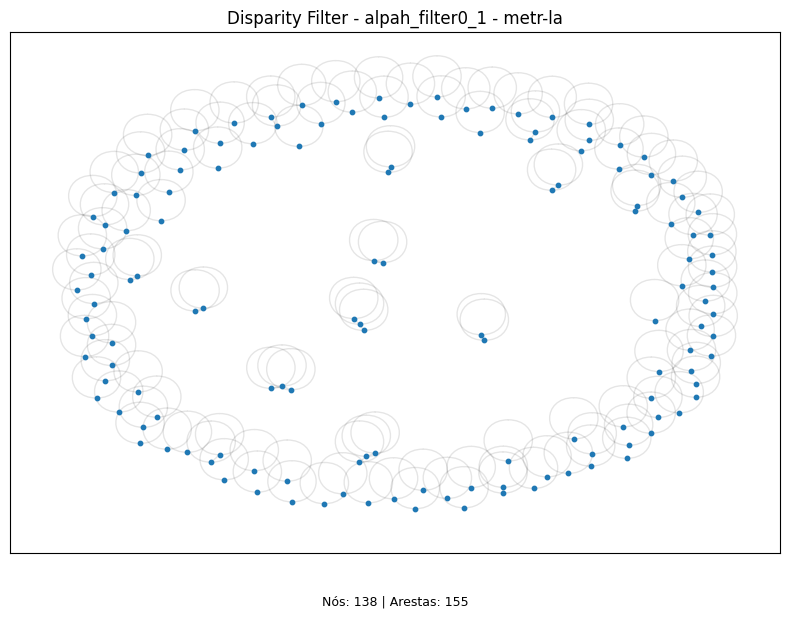

  Nós originais: 207
  Arestas originais: 1520
  Nós filtrados: 206
  Arestas filtradas: 1065
  Redução: 29.9%
Disparity Filter - percen_filter0_3 - metr-la:
  Nós: 206
  Arestas: 1065
  Redução de arestas: 0.0%
O grafo é Direcionado: False


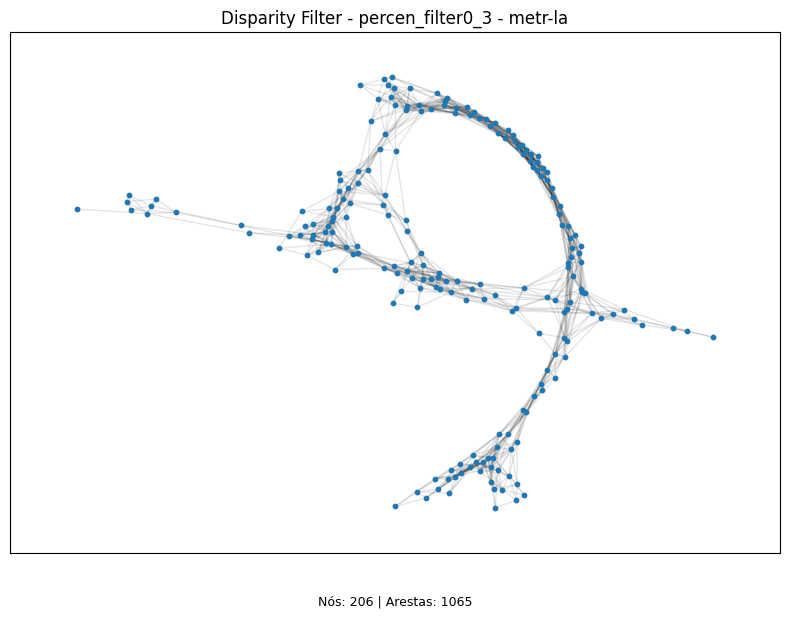

  Nós originais: 207
  Arestas originais: 1520
  Nós filtrados: 207
  Arestas filtradas: 585
  Redução: 61.5%
Noise Corrected Filter - alpah_filter0_1 - metr-la:
  Nós: 207
  Arestas: 585
  Redução de arestas: 0.0%
O grafo é Direcionado: False


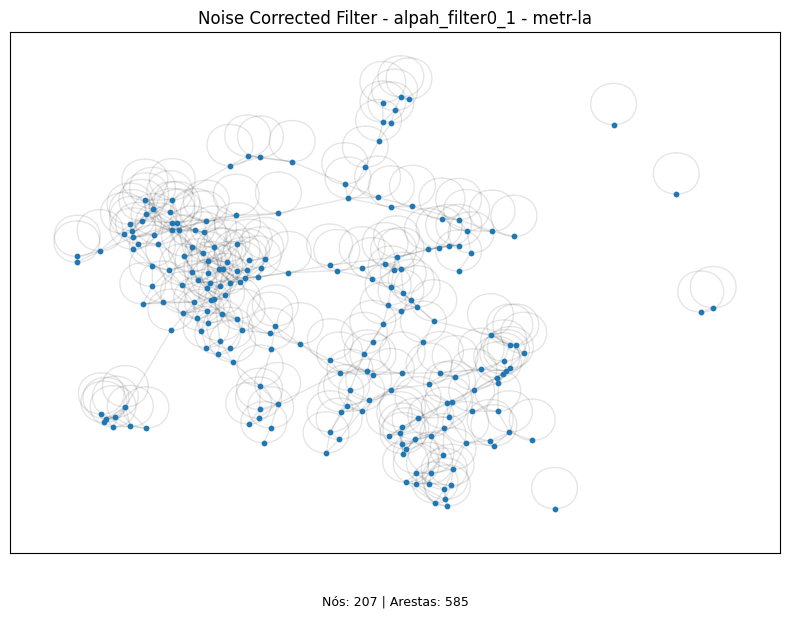

  Nós originais: 207
  Arestas originais: 1520
  Nós filtrados: 207
  Arestas filtradas: 1127
  Redução: 25.9%
Noise Corrected Filter - percen_filter0_3 - metr-la:
  Nós: 207
  Arestas: 1127
  Redução de arestas: 0.0%
O grafo é Direcionado: False


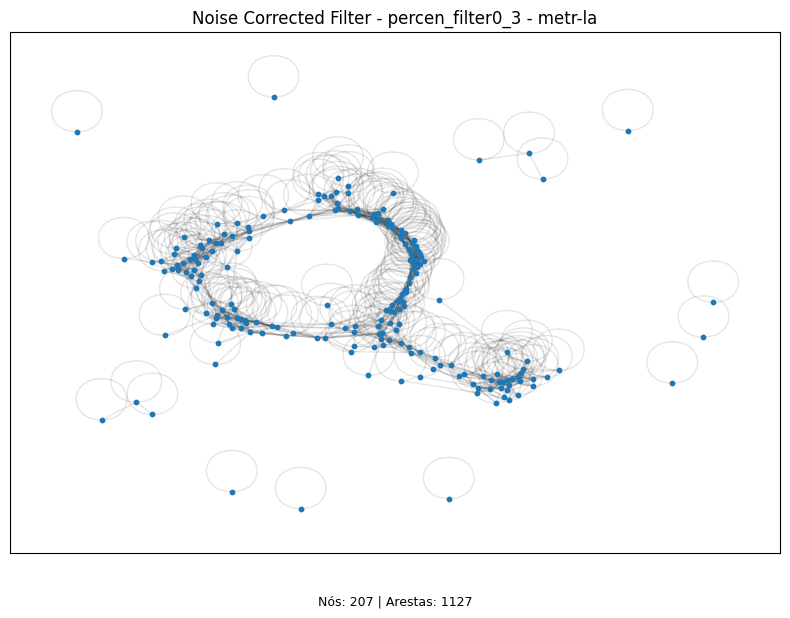

Rede Original - PEMS-BAY:
  Nós: 325
  Arestas: 2404
  Redução de arestas: 0.0%
O grafo é Direcionado: False


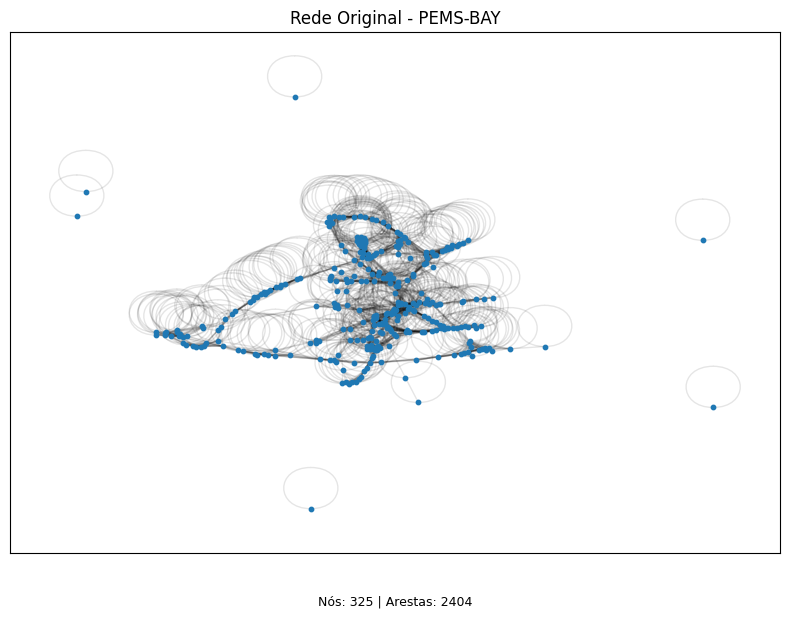

  Nós originais: 325
  Arestas originais: 2404
  Nós filtrados: 53
  Arestas filtradas: 60
  Redução: 97.5%
Disparity Filter - alpah_filter0_1 - pems-bay:
  Nós: 53
  Arestas: 60
  Redução de arestas: 0.0%
O grafo é Direcionado: False


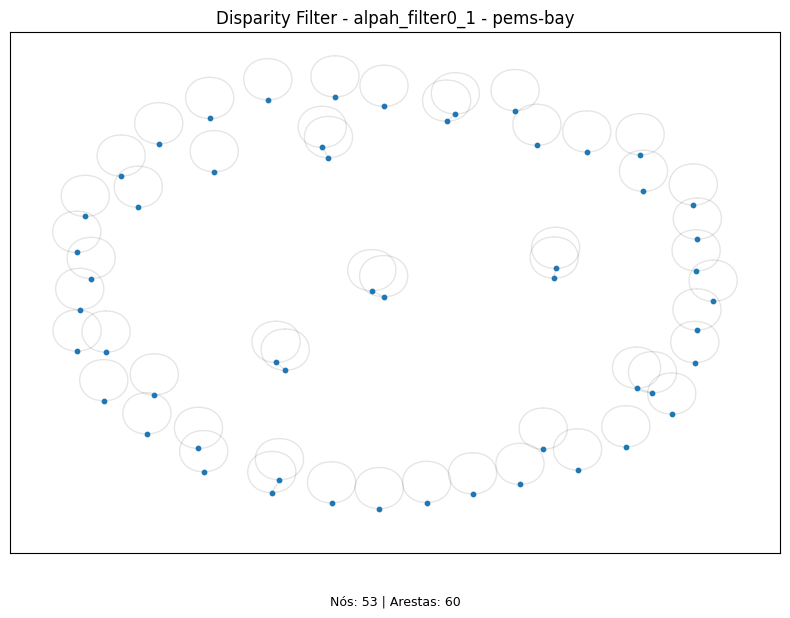

  Nós originais: 325
  Arestas originais: 2404
  Nós filtrados: 319
  Arestas filtradas: 1683
  Redução: 30.0%
Disparity Filter - percen_filter0_3 - pems-bay:
  Nós: 319
  Arestas: 1683
  Redução de arestas: 0.0%
O grafo é Direcionado: False


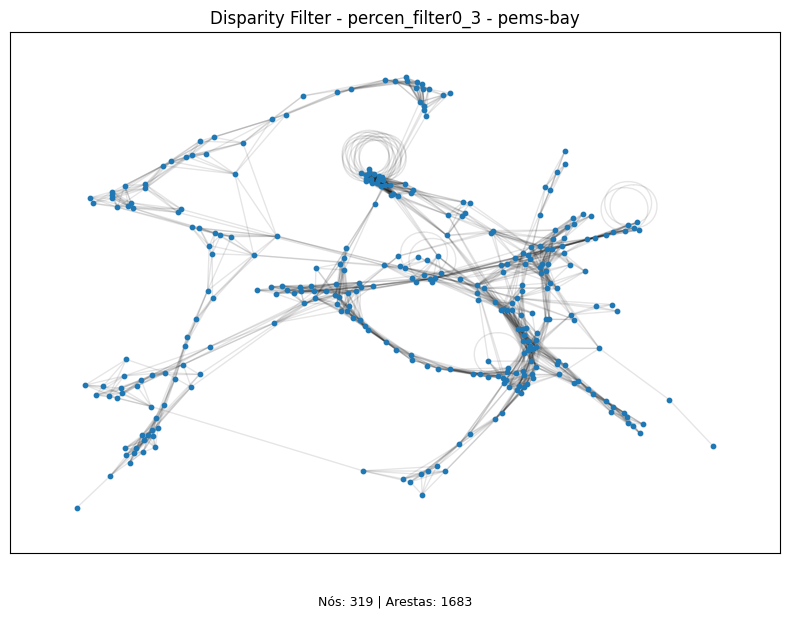

  Nós originais: 325
  Arestas originais: 2404
  Nós filtrados: 325
  Arestas filtradas: 1266
  Redução: 47.3%
Noise Corrected Filter - alpah_filter0_1 - pems-bay:
  Nós: 325
  Arestas: 1266
  Redução de arestas: 0.0%
O grafo é Direcionado: False


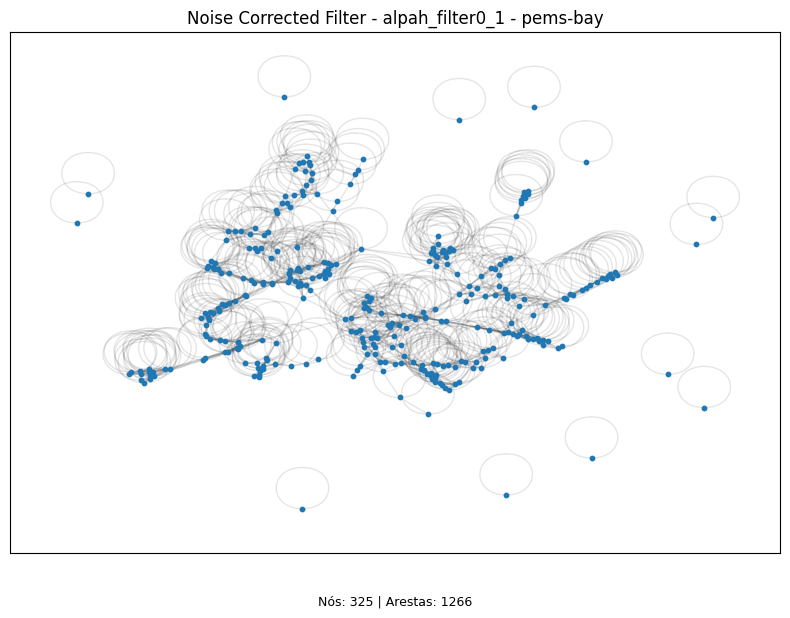

  Nós originais: 325
  Arestas originais: 2404
  Nós filtrados: 325
  Arestas filtradas: 1781
  Redução: 25.9%
Noise Corrected Filter - percen_filter0_3 - pems-bay:
  Nós: 325
  Arestas: 1781
  Redução de arestas: 0.0%
O grafo é Direcionado: False


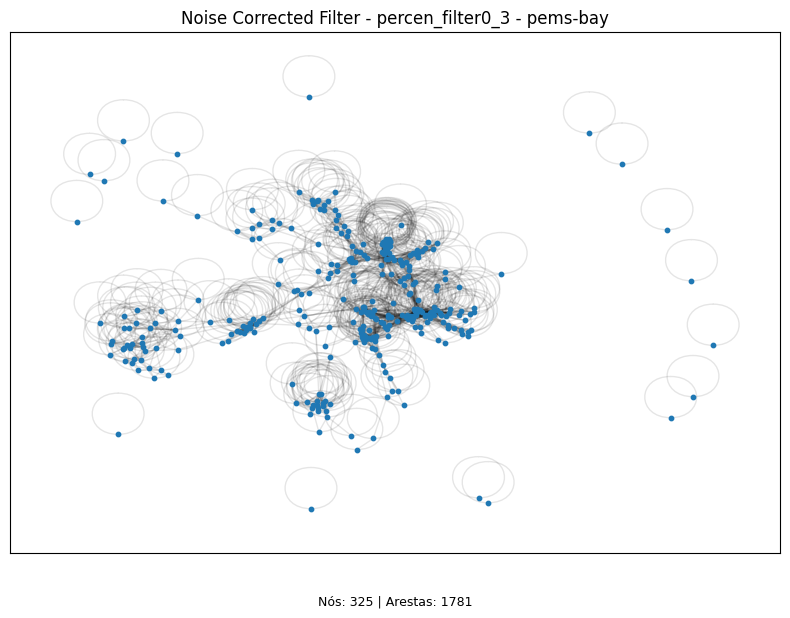

In [15]:

for datat in DATASET_LIST:
    G = generate_graph_from_adjmx_nx(f"../dataset/pkl/{datat}.pkl", datat)
    describe_network(G, "Rede Original - "+datat.upper())
    show_graph(G, titles="Rede Original - "+datat.upper())
    H5Matriz  = np.load(f"../dataset/npy/{datat}.npy")
    
    for comb in combinations:
        method, cut = comb
        output_name = f"{datat}-by-{method}-with-{cut}".strip()
        if method == 'disp_fil':
            df = DisparityFilter(G)
            if cut.startswith('percen'):
                filtered_graph = df.filter_by_percentile(percentile=PERCENTILE, min_degree=MIN_DEGREE)
            else:
                filtered_graph = df.filter_by_alpha(alpha=ALPHA, min_degree=MIN_DEGREE)
            
            if filtered_graph.number_of_nodes() != G.number_of_nodes() :
                updateHT(H5Matriz, df.nodesToKeep, output_name)
            save_filtered_graph(G, filtered_graph, output_name, f'../dataset/pkl/{output_name}.npy')
            describe_network(filtered_graph, f"Disparity Filter - {cut} - {datat}")
            show_graph(filtered_graph, titles=f"Disparity Filter - {cut} - {datat}")
            
        else:
            ncf = NoiseCorrectedFilter(G, undirected=True, use_p_value=False)
            if cut.startswith('percen'):
                filtered_graph = ncf.filter_by_percentile(percentile=0.30, min_degree=MIN_DEGREE)
            else:
                filtered_graph = ncf.filter_by_alpha(alpha=ALPHA, min_degree=MIN_DEGREE)
                
            if(filtered_graph.number_of_nodes() != G.number_of_nodes()):
                updateHT(H5Matriz, df.nodesToKeep, output_name)
            save_filtered_graph(G, filtered_graph,output_name, f'../dataset/pkl/{output_name}.pkl')
            describe_network(filtered_graph, f"Noise Corrected Filter - {cut} - {datat}")
            show_graph(filtered_graph, titles=f"Noise Corrected Filter - {cut} - {datat}")